In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [9]:
# Load gambar
img_path = "images/blackhead.jpg"
img = np.array(Image.open(img_path).convert("RGB"))

# Convert ke BGR untuk OpenCV
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

# Convert ke HSV untuk deteksi warna gelap/merah
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)


In [10]:
# Threshold warna gelap (blackhead)
lower_dark = np.array([0, 0, 0])
upper_dark = np.array([180, 255, 80])
mask_dark = cv2.inRange(img_hsv, lower_dark, upper_dark)


In [11]:
# Threshold warna merah (jerawat merah)
lower_red = np.array([0, 50, 50])
upper_red = np.array([10, 255, 255])
mask_red = cv2.inRange(img_hsv, lower_red, upper_red)


In [12]:
# Gabungkan mask
mask = cv2.bitwise_or(mask_dark, mask_red)

# Hilangkan noise
kernel = np.ones((3,3), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.dilate(mask, kernel, iterations=1)

# Temukan contour (bentuk jerawat)
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

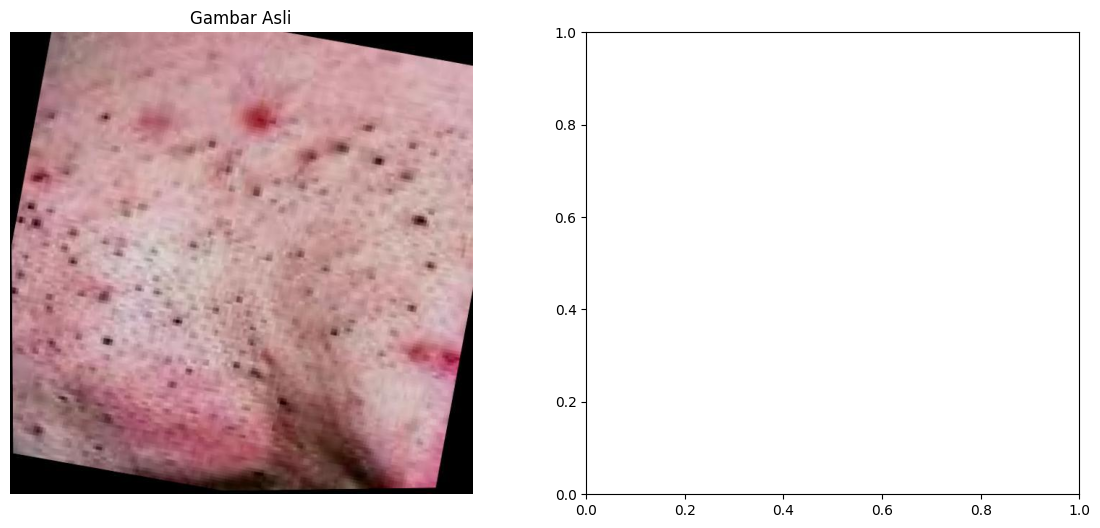

In [13]:
# Gambar kotak merah
img_result = img.copy()
jumlah_jerawat = 0
for contour in contours:
    area = cv2.contourArea(contour)
    if area > 20:  # filter noise kecil
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(img_result, (x, y), (x+w, y+h), (255, 0, 0), 2)
        jumlah_jerawat += 1

# Tampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img)
axes[0].set_title('Gambar Asli')
axes[0].axis('off')


Total jerawat terdeteksi: 41


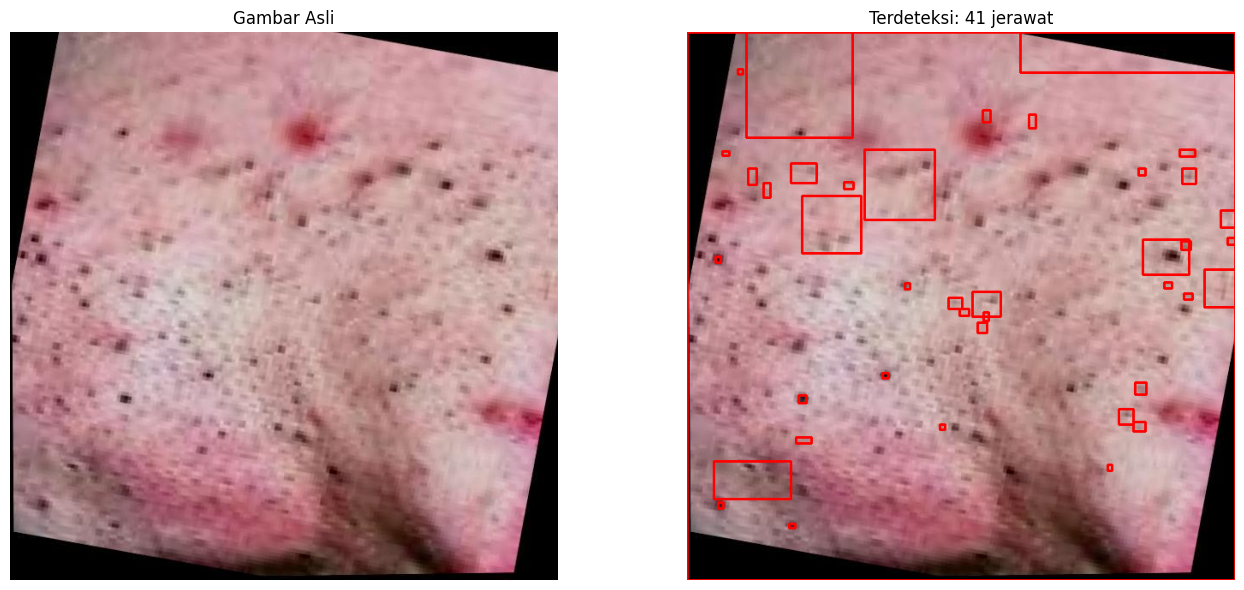

In [14]:
print(f"Total jerawat terdeteksi: {jumlah_jerawat}")

# Tampilkan pakai IPython display
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img)
axes[0].set_title('Gambar Asli')
axes[0].axis('off')

axes[1].imshow(img_result)
axes[1].set_title(f'Terdeteksi: {jumlah_jerawat} jerawat')
axes[1].axis('off')

plt.tight_layout()
display(fig)
plt.close()